# (30) Gamma vs Exp: inter-event intervals

**Project: `_GammaRenewalVAE`**

In [1]:
# HIDE CODE


project_name = '_GammaRenewalVAE'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:0, dtype: torch.float32  ———  host: mach

## Inverse Gaussian

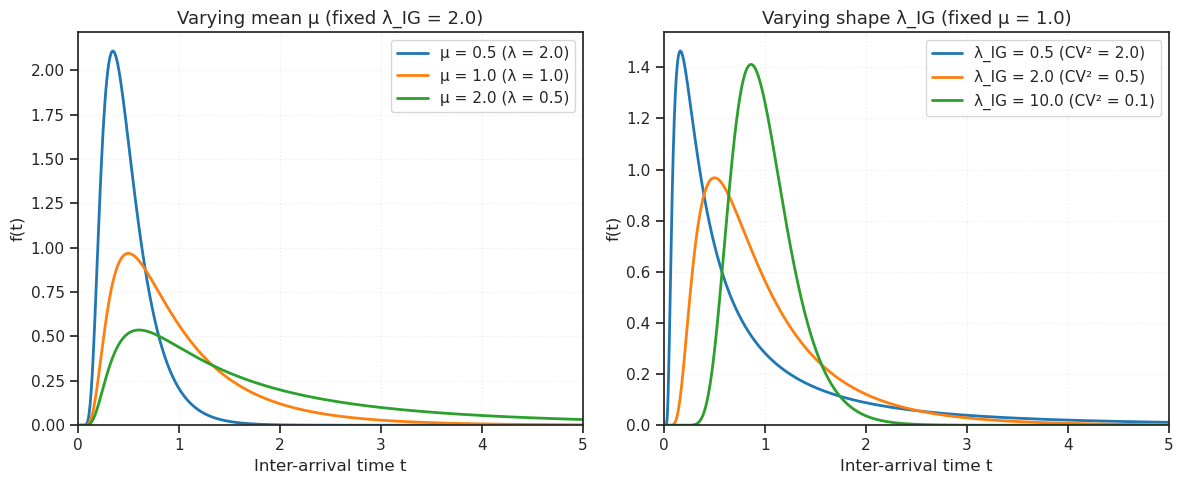

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgauss

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

t = np.linspace(0.001, 5, 1000)

# Left plot: Fix λ_IG, vary μ (i.e., vary firing rate λ = 1/μ)
ax1 = axes[0]
lambda_ig = 2.0  # Fixed shape parameter

for mu in [0.5, 1.0, 2.0]:
    # scipy's invgauss uses different parametrization: mu_scipy = mu / lambda_ig
    # and scale = lambda_ig * mu^2 / lambda_ig = mu
    # Actually scipy uses: f(x, mu) with scale, where mu_scipy = 1/sqrt(lambda_ig) * (1/mu_physical)
    # Let me just compute directly
    
    pdf = np.sqrt(lambda_ig / (2 * np.pi * t**3)) * np.exp(-lambda_ig * (t - mu)**2 / (2 * mu**2 * t))
    rate = 1/mu
    ax1.plot(t, pdf, label=f'μ = {mu} (λ = {rate:.1f})', linewidth=2)

ax1.set_xlabel('Inter-arrival time t', fontsize=12)
ax1.set_ylabel('f(t)', fontsize=12)
ax1.set_title(f'Varying mean μ (fixed λ_IG = {lambda_ig})', fontsize=13)
ax1.legend()
ax1.set_xlim(0, 5)
ax1.set_ylim(0, None)
ax1.grid(True, alpha=0.3)

# Right plot: Fix μ, vary λ_IG (regularity parameter)
ax2 = axes[1]
mu = 1.0  # Fixed mean

for lambda_ig in [0.5, 2.0, 10.0]:
    pdf = np.sqrt(lambda_ig / (2 * np.pi * t**3)) * np.exp(-lambda_ig * (t - mu)**2 / (2 * mu**2 * t))
    cv2 = mu / lambda_ig
    ax2.plot(t, pdf, label=f'λ_IG = {lambda_ig} (CV² = {cv2:.1f})', linewidth=2)

ax2.set_xlabel('Inter-arrival time t', fontsize=12)
ax2.set_ylabel('f(t)', fontsize=12)
ax2.set_title(f'Varying shape λ_IG (fixed μ = {mu})', fontsize=13)
ax2.legend()
ax2.set_xlim(0, 5)
ax2.set_ylim(0, None)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/home/claude/ig_pdf.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Plot saved!")

## Plot Gamma

In [11]:
from scipy.stats import gamma
import math


def plot_gamma_families(rates, ks, n_cols=3):
    """
    Plots Gamma distribution families for different firing rates and shape parameters.
    
    Parameters:
    - rates: list of rates (lambda) [events/unit_time]
    - ks: list of shape parameters (k)
    - n_cols: number of columns in the subplot grid
    """
    n_plots = len(rates)
    n_rows = math.ceil(n_plots / n_cols)
    
    # Create figure
    fig, axes = create_figure(
        n_rows,
        n_cols,
        sharex='all',
        figsize=(4 * n_cols, 3 * n_rows),
        dpi=200,
    )
    axes_flat = np.atleast_1d(axes).flatten()
    
    # Color palette for k != 1
    # We exclude black/gray to reserve it for k=1
    colors = plt.cm.plasma(np.linspace(0, 0.85, len(ks)))

    for i, rate in enumerate(rates):
        ax = axes_flat[i]
        
        # Dynamic x-range: 
        # Plot up to 4 times the mean interval (1/rate) to show the tail
        x_max = 4.0 / rate
        x = np.linspace(0, x_max, 500)
        
        for j, k in enumerate(ks):
            # Biophysical mapping:
            # Mean Interval mu = k * theta
            # Rate lambda = 1 / mu  =>  mu = 1/lambda
            # Therefore: theta = 1 / (k * lambda)
            theta = 1.0 / (k * rate)
            
            y = gamma.pdf(x, a=k, scale=theta)
            
            # Styling logic
            if k == 1:
                ax.plot(x, y, color='black', linestyle='--', linewidth=2, label=f'k={k} (Exp)')
            else:
                ax.plot(x, y, color=colors[j], linestyle='-', linewidth=2, alpha=0.8, label=f'k={k}')
        
        ax.set_title(f"Rate $\lambda = {rate}$")
        ax.set_xlabel("Inter-arrival Time $\Delta t$")
        ax.set_ylabel("Probability Density")
        # ax.set_xlim(0, x_max)
        ax.set_ylim(bottom=-0.01)
        
        # Only add legend to the first plot to avoid clutter
        if i == 0:
            ax.legend()

    # Hide unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    return fig

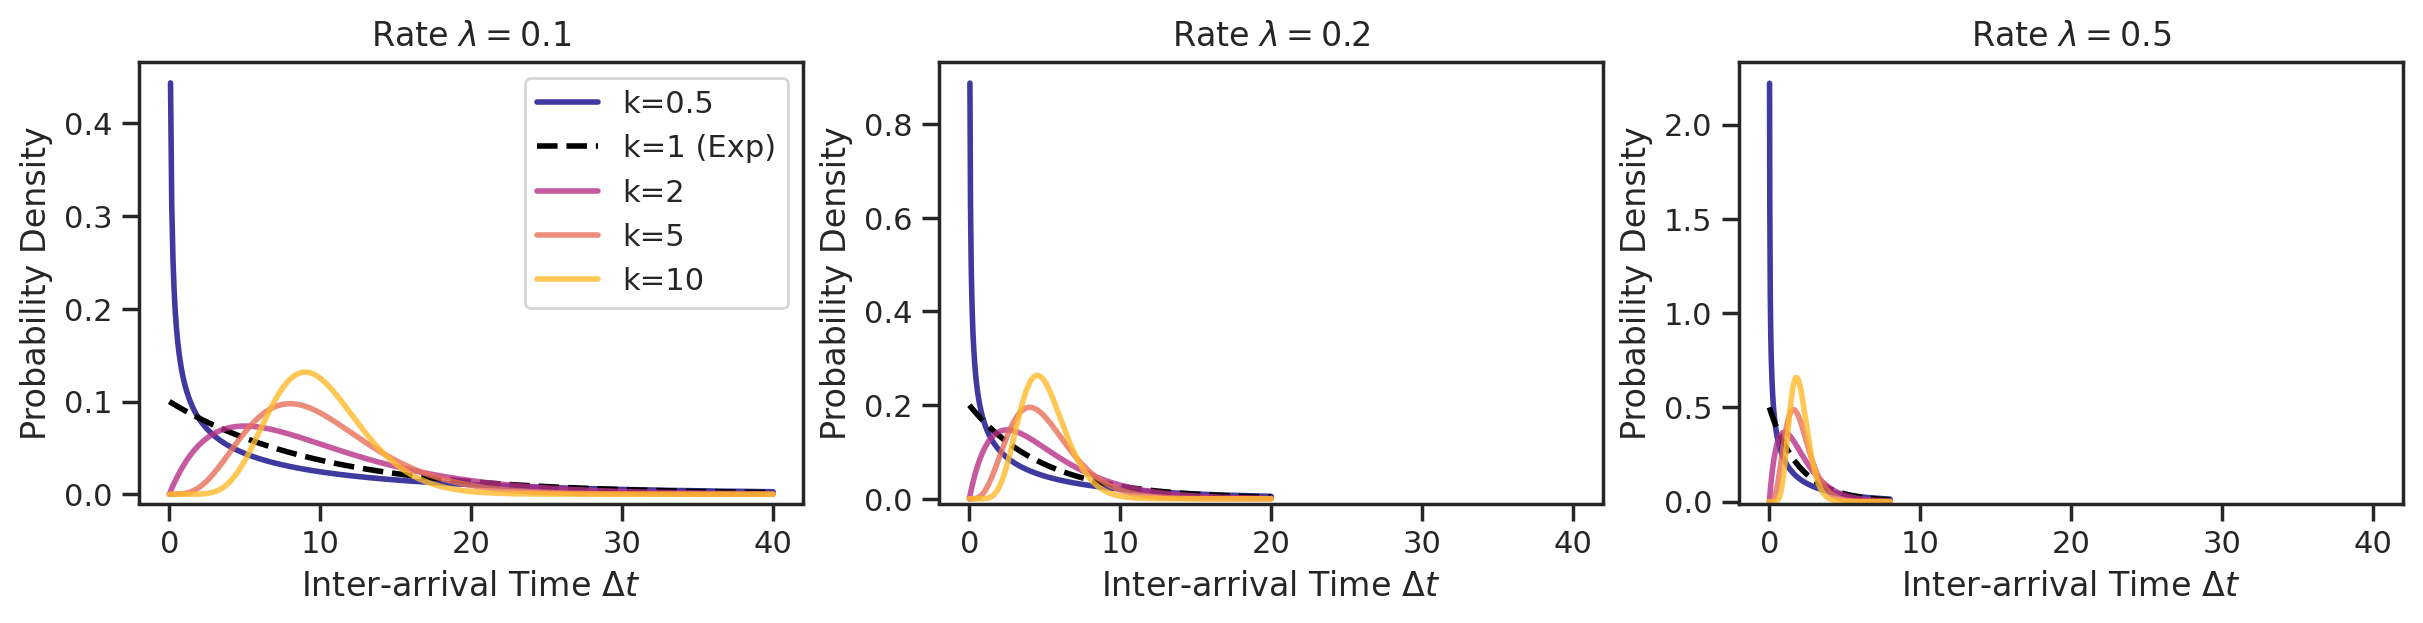

In [15]:
# --- Usage Example ---
lambdas = [0.1, 0.2, 0.5]
shapes = [0.5, 1, 2, 5, 10]

fig = plot_gamma_families(lambdas, shapes, n_cols=3)
plt.show()

## plot adaptive selection of k

Formula:

$k = 1 + \text{Softplus}\left( \frac{\lambda \delta_{\text{ref}}}{1 - \lambda \delta_{\text{ref}}} \right).$

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def softplus(x):
    # Numerical stability for large x
    return np.where(x > 20, x, np.log(1 + np.exp(x)))

def calculate_k(lam, delta_ref, use_softplus=True):
    # The argument of the softplus: x = (lambda * delta) / (1 - lambda * delta)
    # Note: This has a singularity at lambda = 1/delta.
    # Physically, lambda cannot exceed 1/delta.

    product = lam * delta_ref

    if use_softplus:
        # We mask values where rate exceeds physical limit
        denominator = 1 - product

        # Initialize k with NaNs (for plotting gaps)
        k_values = np.full_like(lam, np.nan)

        # Only compute for valid physically possible rates
        valid = denominator > 0

        argument = (product[valid]) / denominator[valid]

        k_values[valid] = 1 + softplus(argument)
        
    else:
        k_values = 1 + product

    return k_values


def visualize_adaptive_regularity(use_softplus=True):
    """
    Visualizes the adaptive regularity k as a function of firing rate lambda
    for different refractory periods delta_ref.
    """

    # 1. Setup the Plot Domain
    # We'll look at rates from 0 to 200 Hz
    lambdas = np.linspace(0, 200, 1000)

    # 2. Define Refractory Periods to compare (in seconds)
    deltas = [0.002, 0.005, 0.010] # 2ms, 5ms, 10ms
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    fig, ax = create_figure(figsize=(10, 6), dpi=100)

    # 3. Plot Curves
    for delta, color in zip(deltas, colors):
        k = calculate_k(lambdas, delta, use_softplus=use_softplus)
        
        # Calculate the asymptote (max physical rate)
        max_rate = 1/delta
        
        plt.plot(lambdas, k, label=f'$\\delta_{{ref}} = {delta*1000:.0f}$ ms', color=color, linewidth=2.5)
        
        # Add vertical line for asymptote
        if max_rate <= 200:
            plt.axvline(max_rate, color=color, linestyle=':', alpha=0.5)

    # 4. Styling
    if use_softplus:
        lbl = r"$k = 1 + \text{Softplus}\left( \frac{\lambda \delta}{1 - \lambda \delta} \right)$"
    else:
        lbl = r"$k = 1 + \lambda \delta$"
    plt.title('Adaptive Regularity: ' + lbl, fontsize=14)
    plt.xlabel(r'Firing Rate $\lambda$ (Hz)', fontsize=12)
    plt.ylabel(r'Shape Parameter $k$', fontsize=12)
    
    # Add Poisson Baseline
    plt.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Poisson ($k=1$)')
    
    if use_softplus:
        plt.ylim(0, 15)
        # Annotation for regimes
        plt.text(10, 1.5, 'Sparse Regime\n(Poisson-like)', fontsize=10, color='gray')
        plt.text(170, 10, 'Saturation Regime\n(Crystal-like)', fontsize=10, color='gray', ha='right')
    else:
        pass
        # plt.ylim(0, 5)
    plt.xlim(0, 200)
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)

    plt.show()

/tmp/ipykernel_939540/3456889715.py:7: RuntimeWarning: overflow encountered in exp
  return np.where(x > 20, x, np.log(1 + np.exp(x)))


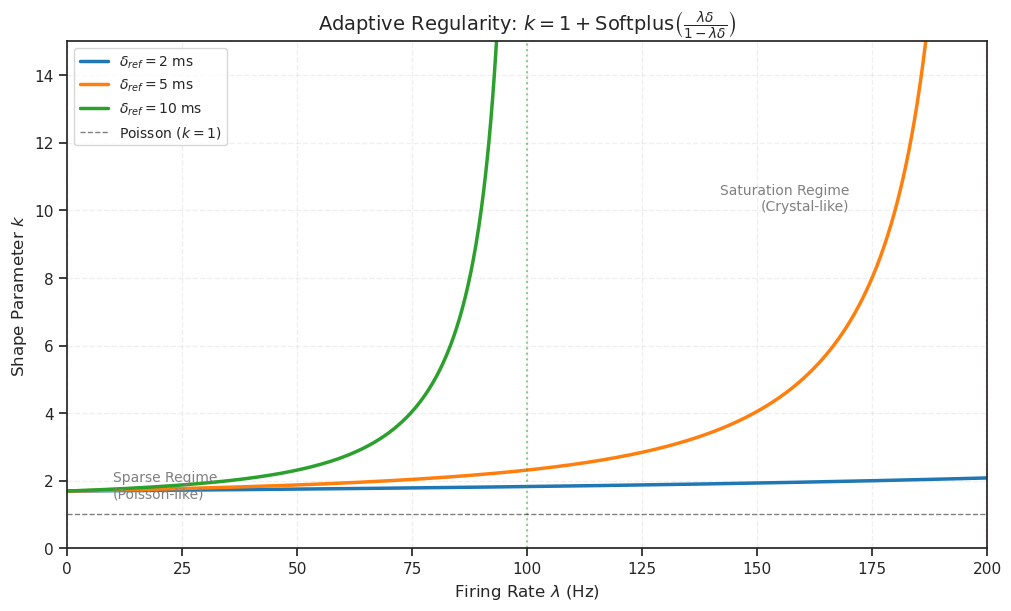

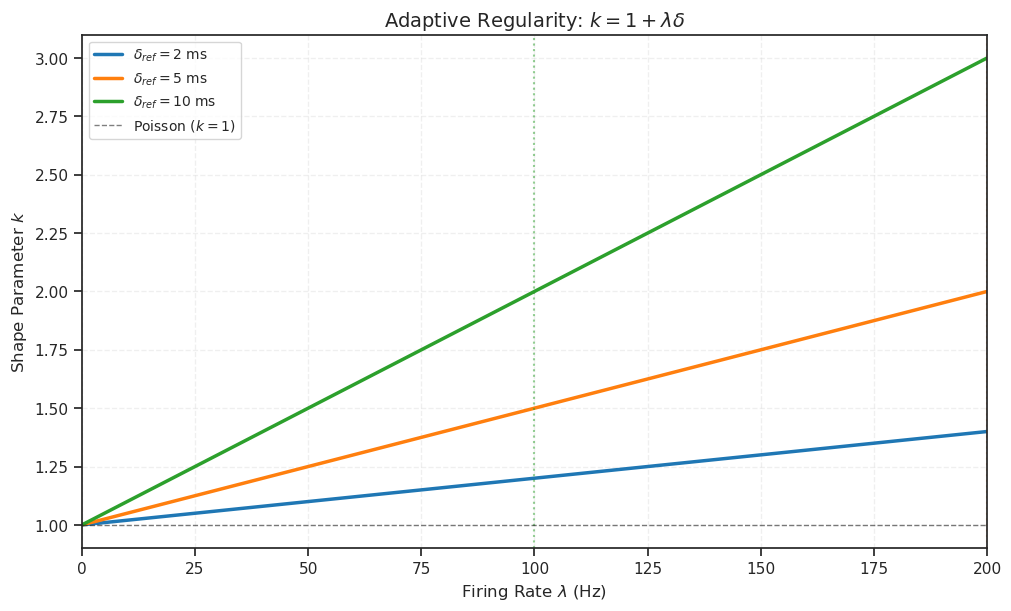

In [30]:
visualize_adaptive_regularity(use_softplus=True)
visualize_adaptive_regularity(use_softplus=False)